In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("C:/Users/Admin/Downloads/studentsPerformance.csv")

# Display first rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,mathscore,readingscore,writingscore
0,female,group B,bachelor's degree,standard,none,72.0,72,74
1,female,group C,some college,standard,completed,69.0,90,88
2,female,group B,master's degree,standard,none,90.0,95,93
3,male,group A,associate's degree,free/reduced,none,47.0,57,44
4,male,group C,some college,standard,none,76.0,78,75


In [2]:
print(df.isnull().sum())

gender                          0
race/ethnicity                  0
parental level of education     0
lunch                           0
test preparation course         0
mathscore                      15
readingscore                    0
writingscore                    0
dtype: int64


In [3]:
print(df.dtypes)

gender                          object
race/ethnicity                  object
parental level of education     object
lunch                           object
test preparation course         object
mathscore                      float64
readingscore                     int64
writingscore                     int64
dtype: object


In [4]:
print(df.duplicated().sum())

0


In [6]:
#Fill numeric columns with mean
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [7]:
#Fill categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_21528\4247093924.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [8]:
#Remove duplicates
df.drop_duplicates(inplace=True)

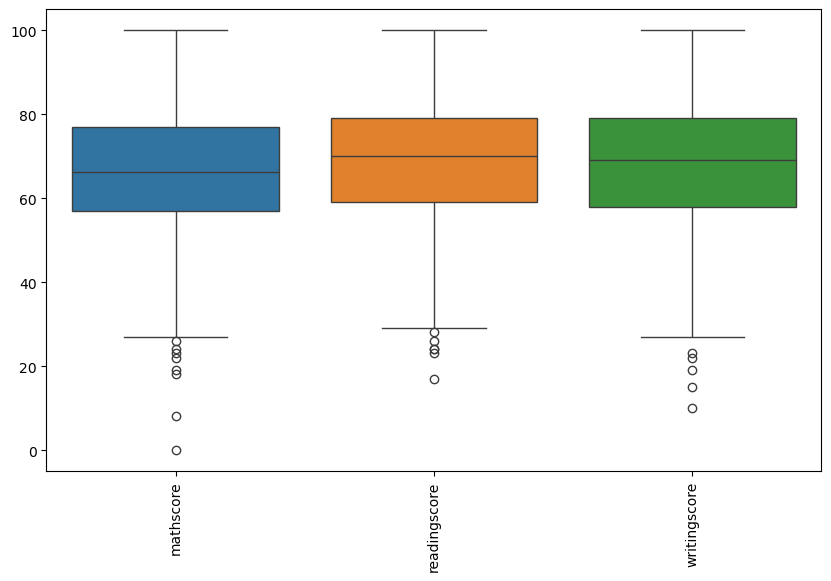

In [9]:
#Scan Numeric Variables for Outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [10]:
#Identify Outliers (Using IQR Method)
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR)))
print(outliers.sum())

mathscore       8
readingscore    6
writingscore    5
dtype: int64


In [11]:
#Remove Outliers
df_clean = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | 
                (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

Original Shape: (1000, 8)
Cleaned Shape: (988, 8)


In [12]:
print(df_clean.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  mathscore  readingscore  writingscore  
0                    none       72.0            72            74  
1               completed       69.0            90            88  
2                    none       90.0            95            93  
3                    none       47.0            57            44  
4                    none       76.0            78            75  
